## Forecasting with the Holt-Winters Method

+ Alias    Description
+ B        business day frequency
+ C        custom business day frequency
+ D        calendar day frequency
+ W        weekly frequency
+ M        month end frequency
+ SM       semi-month end frequency (15th and end of month)
+ BM       business month end frequency
+ CBM      custom business month end frequency
+ MS       month start frequency
+ SMS      semi-month start frequency (1st and 15th)
+ BMS      business month start frequency
+ CBMS     custom business month start frequency
+ Q        quarter end frequency
+ BQ       business quarter end frequency
+ QS       quarter start frequency
+ BQS      business quarter start frequency
+ A, Y     year end frequency
+ BA, BY   business year end frequency
+ AS, YS   year start frequency
+ BAS, BYS business year start frequency
+ BH       business hour frequency
+ H        hourly frequency
+ T, min   minutely frequency
+ S        secondly frequency
+ L, ms    milliseconds
+ U, us    microseconds
+ N        nanoseconds

https://tedboy.github.io/pandas/computation/computation5.html

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('airline-passengers.csv',index_col='Month',parse_dates=True)
df.index.freq = 'MS'
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [62]:
df1 = pd.read_csv('airline-passengers.csv',index_col='Month',parse_dates=True)

In [64]:
df1.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [66]:
#mydf = pd.read_csv('airline_passengers.csv')
#mydf

In [68]:
df.tail()

,Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


## Train Test Split

In [73]:
train_data = df.iloc[:108] 
test_data = df.iloc[108:]

In [75]:
train_data.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


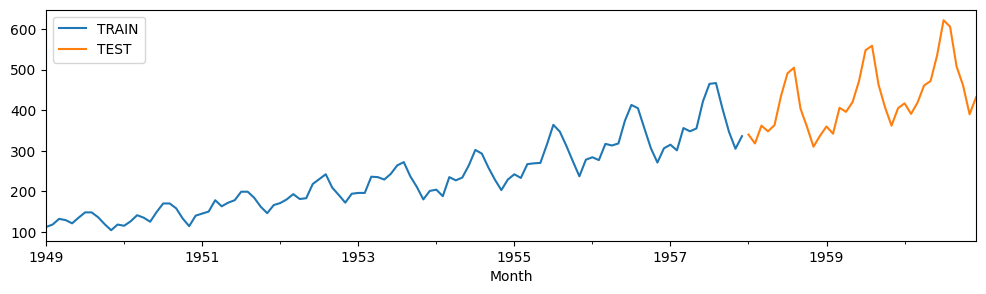

In [77]:
train_data['Passengers'].plot(legend=True,label='TRAIN')
test_data['Passengers'].plot(legend=True,label='TEST',figsize=(12,3));
plt.show()

## Fitting the Model

In [80]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(train_data['Passengers'],trend='mul',seasonal='mul',seasonal_periods=12)
fitted_model = model.fit()

In [81]:
fitted_model

## Evaluating Model against Test Set

In [85]:
test_predictions = fitted_model.forecast(36)

In [87]:
test_predictions

1958-01-01   NaN
1958-02-01   NaN
1958-03-01   NaN
1958-04-01   NaN
1958-05-01   NaN
1958-06-01   NaN
1958-07-01   NaN
1958-08-01   NaN
1958-09-01   NaN
1958-10-01   NaN
1958-11-01   NaN
1958-12-01   NaN
1959-01-01   NaN
1959-02-01   NaN
1959-03-01   NaN
1959-04-01   NaN
1959-05-01   NaN
1959-06-01   NaN
1959-07-01   NaN
1959-08-01   NaN
1959-09-01   NaN
1959-10-01   NaN
1959-11-01   NaN
1959-12-01   NaN
1960-01-01   NaN
1960-02-01   NaN
1960-03-01   NaN
1960-04-01   NaN
1960-05-01   NaN
1960-06-01   NaN
1960-07-01   NaN
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Freq: MS, dtype: float64

In [54]:
#train_data['Thousands of Passengers'].plot(legend=True,label='TRAIN')
#test_data['Thousands of Passengers'].plot(legend=True,label='TEST',figsize=(12,8));

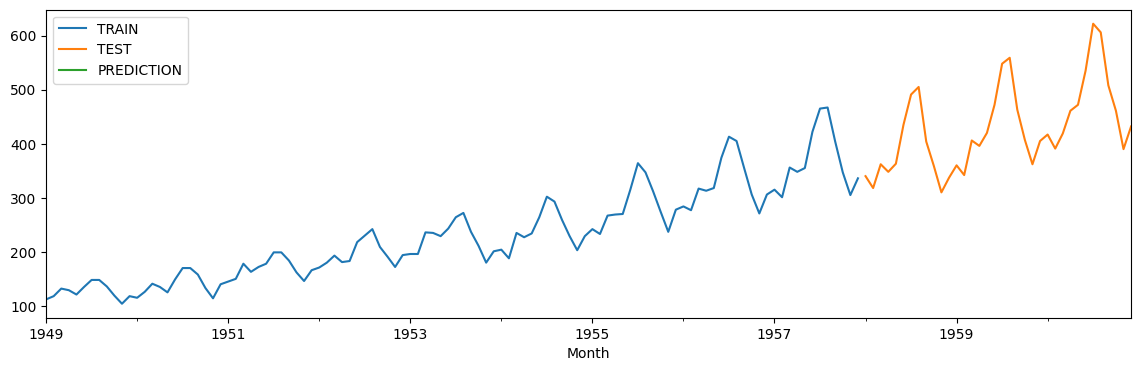

In [56]:
train_data['Passengers'].plot(legend=True,label='TRAIN')
test_data['Passengers'].plot(legend=True,label='TEST',figsize=(14,4))
test_predictions.plot(legend=True,label='PREDICTION');
plt.show()

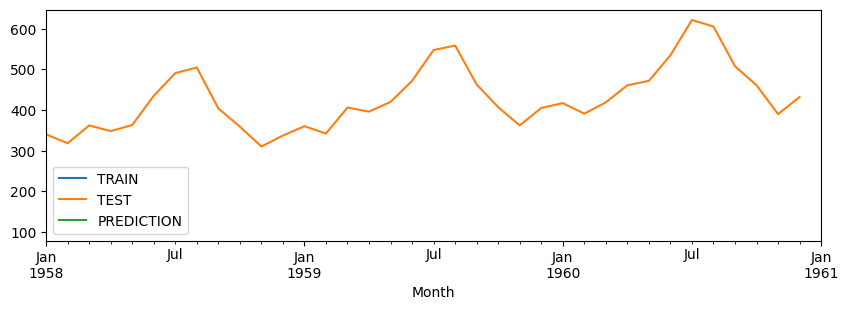

In [58]:
train_data['Passengers'].plot(legend=True,label='TRAIN')
test_data['Passengers'].plot(legend=True,label='TEST',figsize=(10,3))
test_predictions.plot(legend=True,label='PREDICTION',xlim=['1958-01-01','1961-01-01']);
plt.show()

## Evaluation Metrics

In [26]:
from sklearn.metrics import mean_squared_error

In [27]:
mean_squared_error(test_data,test_predictions)

3525.914824738568

In [28]:
np.sqrt(mean_squared_error(test_data,test_predictions))

59.379414149506125

In [ ]:
test_data.describe()

## Forecasting into Future

In [29]:
final_model = ExponentialSmoothing(df['Passengers'],trend='mul',seasonal='mul',seasonal_periods=12).fit()

In [30]:
forecast_predictions = final_model.forecast(36)

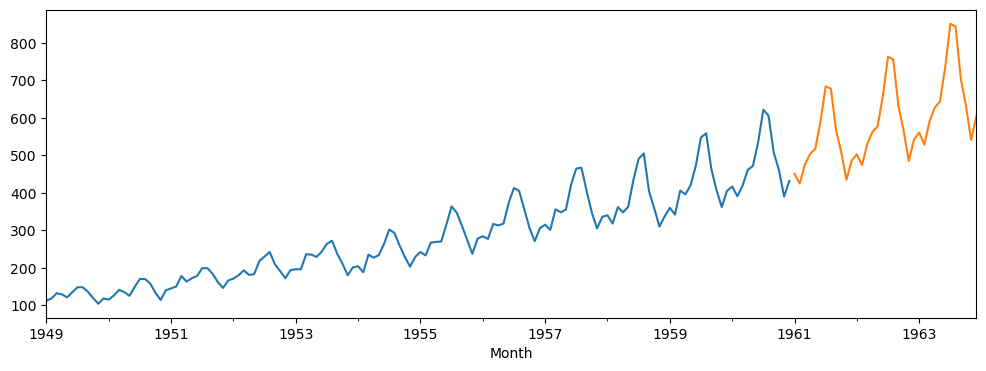

In [32]:
df['Passengers'].plot(figsize=(12,4))
forecast_predictions.plot();
plt.show()